In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from scipy import stats
from scipy.interpolate import griddata
# import xesmf as xe
from pathlib import Path
import cartopy.crs as ccrs
import netCDF4  
import time
# import mpl_toolkits.basemap
# import pyresample 
import utils as u

In [2]:
month_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season_list = ["DJF","MAM","JJA","SON"]

### MAR

In [3]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRf.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

In [4]:
print('Fedchenko domain')
print('lon min',ds_grF.LON.values.min(),'lon max',ds_grF.LON.values.max())
print('lat min',ds_grF.LAT.values.min(),'lat max',ds_grF.LAT.values.max())

latlim_grF=slice(ds_grF.LAT.values.min(),ds_grF.LAT.values.max())
lonlim_grF=slice(ds_grF.LON.values.min(),ds_grF.LON.values.max())

Fedchenko domain
lon min 67.45302 lon max 77.20667
lat min 36.148087 lat max 41.407486


In [5]:
sourceData='/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRf/spin2/work/monthly/'
variable='TTZ' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_GRf_2000-2023.nc'
dsF= xr.open_dataset(sourceData+fileNameF).isel(ZTQLEV=0).TTZ.load()

dsF = dsF.assign_coords(X=np.round(dsF.X.values))
dsF = dsF.assign_coords(Y=np.round(dsF.Y.values))
dsF = dsF.rename({'TIME': 'time'})

### ERA5-land

In [6]:
# ERA5-Land data coverage is only 2000 - 2023
folder_era5land='/bettik/PROJECTS/pr-regional-climate/observations/ERA5-land/'
tmp_era5land = xr.open_mfdataset(folder_era5land + 'era5_land_GRf_t2m.nc').t2m.load()-273.15

tmp_era5land=tmp_era5land.rename({'latitude':'lat', 'longitude':'lon'})
tmp_era5land = tmp_era5land.rename({'valid_time': 'time'})

OSError: no files to open

In [ ]:
# ERA5-land orography
orog_era5land= xr.open_dataset(folder_era5land + 'geo.area-subset.42.78.36.66.nc').z.isel(time=0).load()/9.80665
print(orog_era5land.shape)
orog_era5land[:,:].plot()

### ERA5

In [ ]:
# ERA5 data coverage is only 2000 - 2023
folder_era5='/bettik/PROJECTS/pr-regional-climate/observations/ERA5/'
tmp_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').t2m.load()-273.15
tmp_era5=tmp_era5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})

In [ ]:
# ERA5 orography
orog_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').z.isel(valid_time=0).load()/9.80665
orog_era5=orog_era5.rename({'latitude':'lat', 'longitude':'lon'})
print(orog_era5.shape)
orog_era5[:,:].plot()

### CRU

In [ ]:
# Could to download latest version of CRU data
# 2021-2023 data missing

folder_cru='/bettik/PROJECTS/pr-regional-climate/santolam/cru/'
tmp_cru = xr.open_mfdataset(folder_cru + 'cru_ts4.05.1901.2020.tmp.dat.nc').sel(lat=latlim_grF,lon=lonlim_grF).tmp.load()
tmp_cru=tmp_cru.sel(time=tmp_cru.time[np.isin(tmp_cru.time.dt.year,[2000, 2020])])

## MAR vs ERA5-Land

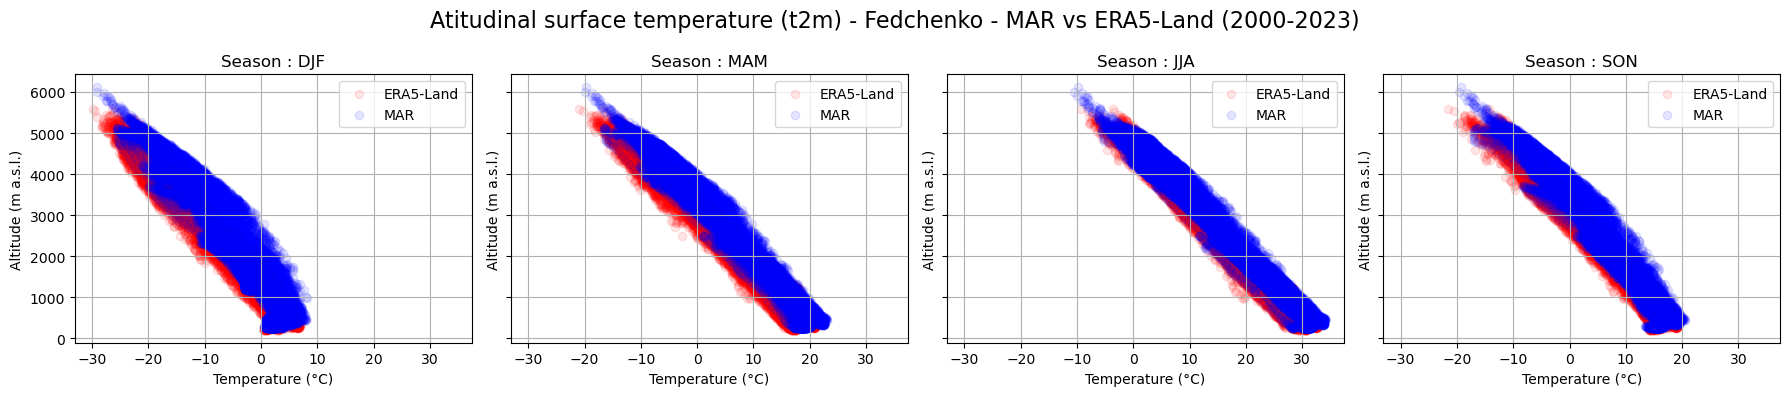

In [11]:
ncols = 4

fig, axs = plt.subplots(ncols=ncols, sharex=True, sharey=True, figsize=(18, 4)) 
axs = axs.flatten() 

for i in range(4):
    ax = axs[i]
    temp_mar = dsF.groupby("time.season").mean('time').sel(season=season_list[i]).values
    temp_mar_flat = temp_mar.reshape(-1) 

    temp_era5land=tmp_era5land.groupby("time.season").mean('time').sel(season=season_list[i]).values
    temp_era5land_flat = temp_era5land.reshape(-1) 

    SH_mar=ds_grF.SH.values.flatten()
    SH_era5land=orog_era5land.values.reshape(-1)

    ax.scatter(temp_era5land_flat, SH_era5land, color='red', label ='ERA5-Land',alpha=0.1)
    ax.scatter(temp_mar_flat, SH_mar, color='blue', label ='MAR',alpha=0.1)
    
    ax.set_title(f"Season : {season_list[i]}")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Altitude (m a.s.l.)")
    ax.grid(True)
    ax.legend()

fig.suptitle('Atitudinal surface temperature (t2m) - Fedchenko - MAR vs ERA5-Land (2000-2023)', fontsize=16)

# plt.savefig("Alti_profiles_raw_MAR_ERA5_Fed.png", dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

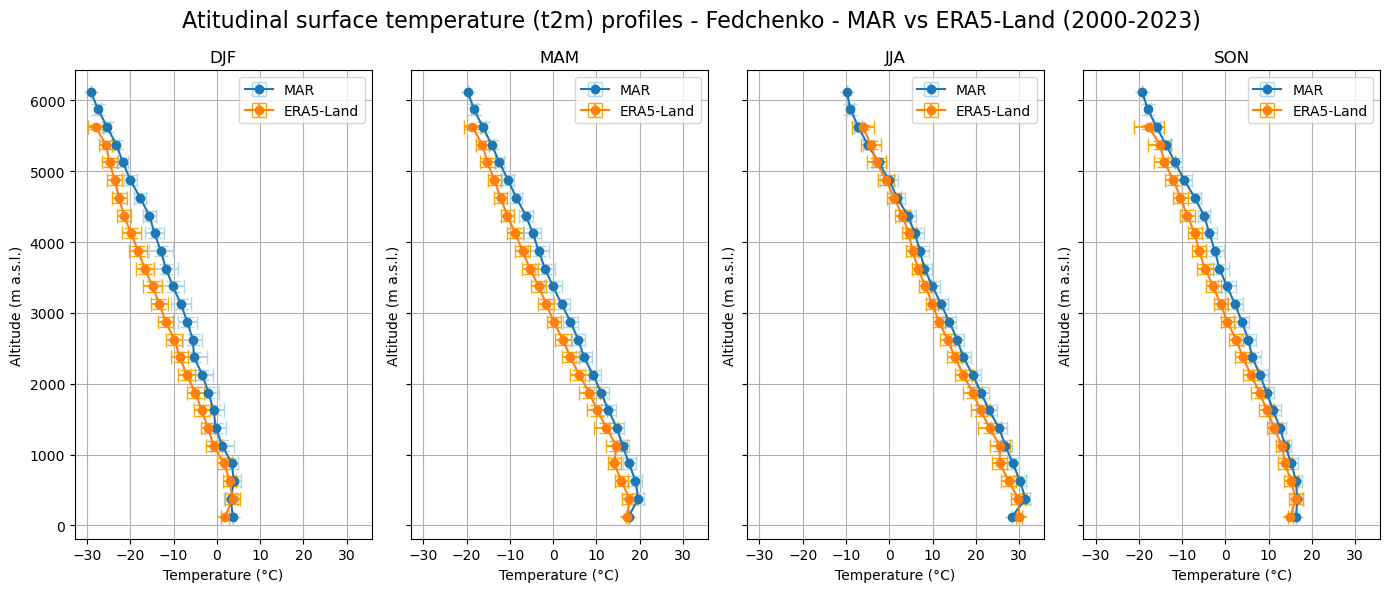

In [12]:
ncols = 4

fig, axs = plt.subplots(ncols=ncols, sharex=True, sharey=True, figsize=(14, 6)) 
axs = axs.flatten() 

SH_mar=ds_grF.SH.values.flatten()
SH_era5land=orog_era5land.values.reshape(-1)

for i in range(4):
    alt_min_mar = int(np.floor(SH_mar.min() / 250) * 250)
    alt_max_mar = int(np.ceil(SH_mar.max() / 250) * 250) 
    bins_mar = np.arange(alt_min_mar, alt_max_mar + 250, 250)
    means_mar = []
    stds_mar = []
    stds_SHmar = []
    bin_centers_mar = []

    alt_min_era5land = int(np.floor(SH_era5land.min() / 250) * 250)
    alt_max_era5land = int(np.ceil(SH_era5land.max() / 250) * 250)     
    bins_era5land = np.arange(alt_min_era5land, alt_max_era5land + 250, 250)
    means_era5land = []
    stds_era5land = []
    stds_SHera5land = []
    bin_centers_era5land = []
    
    ax = axs[i]
    
    temp_mar = dsF.groupby("time.season").mean('time').sel(season=season_list[i]).values
    temp_mar_flat = temp_mar.reshape(-1) 

    temp_era5land=tmp_era5land.groupby("time.season").mean('time').sel(season=season_list[i]).values
    temp_era5land_flat = temp_era5land.reshape(-1)


    for j in range(len(bins_mar) - 1):
        mask_mar = (SH_mar >= bins_mar[j]) & (SH_mar < bins_mar[j + 1])
        temp_mar_in_bin = temp_mar_flat[mask_mar]
        SH_mar_in_bin = SH_mar[mask_mar]
        
        if len(temp_mar_in_bin) > 0:
            means_mar.append(np.mean(temp_mar_in_bin))
            stds_mar.append(np.std(temp_mar_in_bin))
            stds_SHmar.append(np.std(SH_mar_in_bin))
            bin_centers_mar.append((bins_mar[j] + bins_mar[j + 1]) / 2)

    for k in range(len(bins_era5land) - 1):
        mask_era5land = (SH_era5land >= bins_era5land[k]) & (SH_era5land < bins_era5land[k + 1])
        temp_era5land_in_bin = temp_era5land_flat[mask_era5land]    
        SH_era5land_in_bin = SH_era5land[mask_era5land]
        
        if len(temp_era5land_in_bin) > 0:
            means_era5land.append(np.mean(temp_era5land_in_bin))
            stds_era5land.append(np.std( temp_era5land_in_bin))
            stds_SHera5land.append(np.std(SH_era5land_in_bin))
            bin_centers_era5land.append((bins_era5land[k] + bins_era5land[k + 1]) / 2)       
            

    ax.errorbar(means_mar,bin_centers_mar, xerr=stds_mar, yerr=stds_SHmar, fmt='o-', ecolor='lightblue', capsize=5, label ='MAR',)
    ax.errorbar(means_era5land,bin_centers_era5land, xerr=stds_era5land,yerr=stds_SHera5land , fmt='o-', ecolor='orange', capsize=5, label ='ERA5-Land',)
    
    ax.set_title(f"{season_list[i]}")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Altitude (m a.s.l.)")
    ax.grid(True)
    ax.legend()

fig.suptitle('Atitudinal surface temperature (t2m) profiles - Fedchenko - MAR vs ERA5-Land (2000-2023) ', fontsize=16)

plt.savefig("Alti_profiles_MAR_ERA5-Land_Fed.png", dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

## MAR vs ERA5

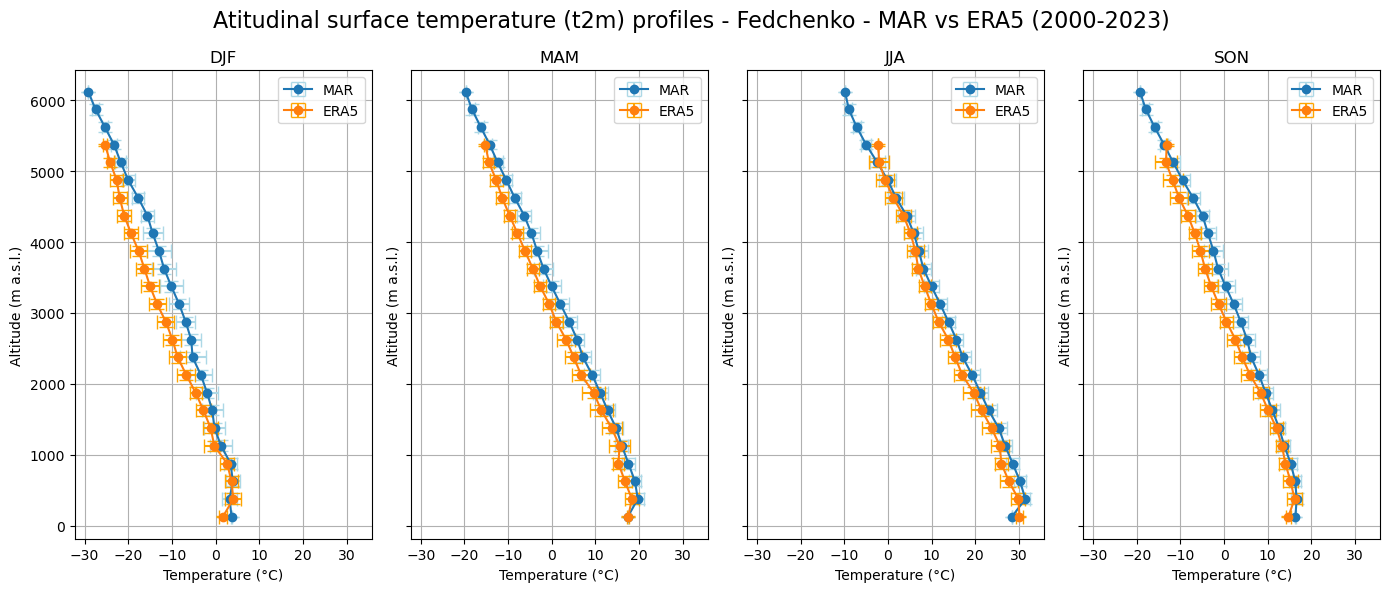

In [13]:
ncols = 4

fig, axs = plt.subplots(ncols=ncols, sharex=True, sharey=True, figsize=(14, 6)) 
axs = axs.flatten() 

SH_mar=ds_grF.SH.values.flatten()
SH_era5=orog_era5.values.reshape(-1)

for i in range(4):
    alt_min_mar = int(np.floor(SH_mar.min() / 250) * 250)
    alt_max_mar = int(np.ceil(SH_mar.max() / 250) * 250) 
    bins_mar = np.arange(alt_min_mar, alt_max_mar + 250, 250)
    means_mar = []
    stds_mar = []
    stds_SHmar = []
    bin_centers_mar = []

    alt_min_era5 = int(np.floor(SH_era5.min() / 250) * 250)
    alt_max_era5 = int(np.ceil(SH_era5.max() / 250) * 250)     
    bins_era5 = np.arange(alt_min_era5, alt_max_era5 + 250, 250)
    means_era5 = []
    stds_era5 = []
    stds_SHera5 = []
    bin_centers_era5 = []
    
    ax = axs[i]
    
    temp_mar = dsF.groupby("time.season").mean('time').sel(season=season_list[i]).values
    temp_mar_flat = temp_mar.reshape(-1) 

    temp_era5=tmp_era5.groupby("time.season").mean('time').sel(season=season_list[i]).values
    temp_era5_flat = temp_era5.reshape(-1)


    for j in range(len(bins_mar) - 1):
        mask_mar = (SH_mar >= bins_mar[j]) & (SH_mar < bins_mar[j + 1])
        temp_mar_in_bin = temp_mar_flat[mask_mar]
        SH_mar_in_bin = SH_mar[mask_mar]
        
        if len(temp_mar_in_bin) > 0:
            means_mar.append(np.mean(temp_mar_in_bin))
            stds_mar.append(np.std(temp_mar_in_bin))
            stds_SHmar.append(np.std(SH_mar_in_bin))
            bin_centers_mar.append((bins_mar[j] + bins_mar[j + 1]) / 2)

    for k in range(len(bins_era5) - 1):
        mask_era5 = (SH_era5 >= bins_era5[k]) & (SH_era5 < bins_era5[k + 1])
        temp_era5_in_bin = temp_era5_flat[mask_era5]    
        SH_era5_in_bin = SH_era5[mask_era5]
        
        if len(temp_era5_in_bin) > 0:
            means_era5.append(np.mean(temp_era5_in_bin))
            stds_era5.append(np.std( temp_era5_in_bin))
            stds_SHera5.append(np.std(SH_era5_in_bin))
            bin_centers_era5.append((bins_era5[k] + bins_era5[k + 1]) / 2)       
            

    ax.errorbar(means_mar,bin_centers_mar, xerr=stds_mar, yerr=stds_SHmar, fmt='o-', ecolor='lightblue', capsize=5, label ='MAR',)
    ax.errorbar(means_era5,bin_centers_era5, xerr=stds_era5,yerr=stds_SHera5 , fmt='o-', ecolor='orange', capsize=5, label ='ERA5',)
    
    ax.set_title(f"{season_list[i]}")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Altitude (m a.s.l.)")
    ax.grid(True)
    ax.legend()

fig.suptitle('Atitudinal surface temperature (t2m) profiles - Fedchenko - MAR vs ERA5 (2000-2023) ', fontsize=16)

plt.savefig("Alti_profiles_MAR_ERA5_Fed.png", dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()